Упражнение 1: MLP с window_size=24
Loaded ElecRome dataset.
Data shape:
  X: (137376, 1)


/home/vlad/Programs/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP с window_size=24: MSE = 22.82
MLP с window_size=12: MSE = 26.97

Комментарий: window_size=24 улучшает качество.
Причина: window_size=24 захватывает полные сутки почасовых данных, соответствуя суточной сезонности.


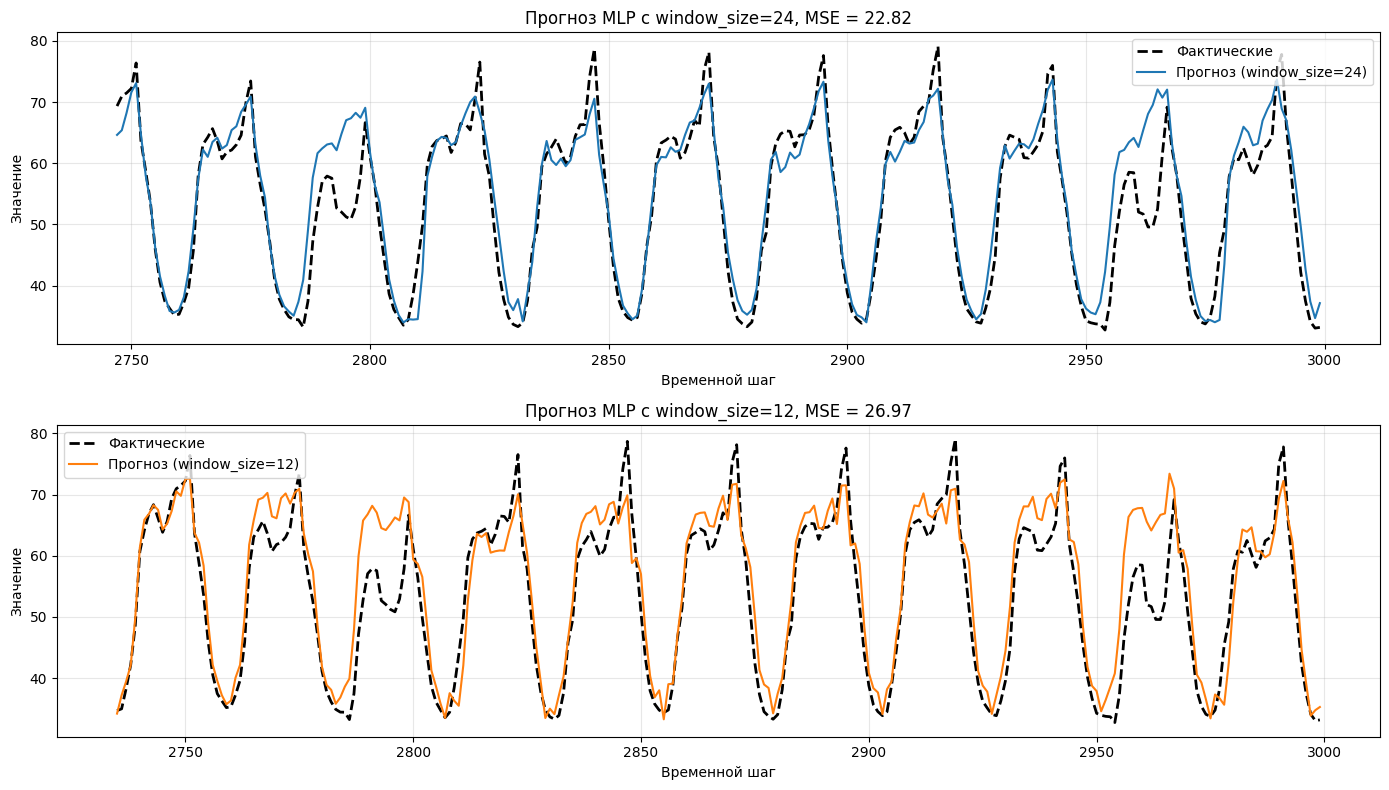

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from reservoir_computing.datasets import PredLoader

# Упражнение 1: Изменить window_size с 12 на 24 в MLP
print("=" * 60)
print("Упражнение 1: MLP с window_size=24")
print("=" * 60)

# Загрузка данных
ts_full = PredLoader().get_data('ElecRome')
ts_hourly = np.mean(ts_full.reshape(-1, 6), axis=1)
time_series = ts_hourly[0:3000]
time_steps = np.arange(0, len(time_series))

# Разделение на train/test
train_size = int(0.9 * len(time_series))
tr = time_series[:train_size]
te = time_series[train_size:]

def create_windows(data, window_size, forecast_horizon):
    X, y = [], []
    for i in range(len(data) - window_size - forecast_horizon + 1):
        X.append(data[i:(i + window_size)])
        y.append(data[i + window_size:i + window_size + forecast_horizon])
    return np.array(X), np.array(y)

# Упражнение 1: window_size = 24 (вместо 12)
window_size = 24
forecast_horizon = 24

X_train, y_train = create_windows(tr, window_size, forecast_horizon)
X_test, y_test = create_windows(te, window_size, forecast_horizon)
y_train = y_train[:, -1]
y_test = y_test[:, -1]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPRegressor(hidden_layer_sizes=(16, 8), activation='relu', solver='adam', max_iter=1000)
mlp.fit(X_train_scaled, y_train)

y_pred = mlp.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print(f"MLP с window_size=24: MSE = {mse:.2f}")

# Сравнение с window_size=12
window_size_old = 12
X_train_old, y_train_old = create_windows(tr, window_size_old, forecast_horizon)
X_test_old, y_test_old = create_windows(te, window_size_old, forecast_horizon)
y_train_old = y_train_old[:, -1]
y_test_old = y_test_old[:, -1]

scaler_old = StandardScaler()
X_train_scaled_old = scaler_old.fit_transform(X_train_old)
X_test_scaled_old = scaler_old.transform(X_test_old)

mlp_old = MLPRegressor(hidden_layer_sizes=(16, 8), activation='relu', solver='adam', max_iter=1000)
mlp_old.fit(X_train_scaled_old, y_train_old)

y_pred_old = mlp_old.predict(X_test_scaled_old)
mse_old = mean_squared_error(y_test_old, y_pred_old)
print(f"MLP с window_size=12: MSE = {mse_old:.2f}")

print(f"\nКомментарий: window_size=24 {'улучшает' if mse < mse_old else 'ухудшает'} качество.")
print("Причина: window_size=24 захватывает полные сутки почасовых данных, соответствуя суточной сезонности.")

# График для Упражнения 1
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(time_steps[-len(y_test):], y_test, label='Фактические', linewidth=2, color='black', linestyle='--')
axes[0].plot(time_steps[-len(y_pred):], y_pred, label='Прогноз (window_size=24)', color='tab:blue')
axes[0].set_title(f'Прогноз MLP с window_size=24, MSE = {mse:.2f}')
axes[0].set_xlabel('Временной шаг')
axes[0].set_ylabel('Значение')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(time_steps[-len(y_test_old):], y_test_old, label='Фактические', linewidth=2, color='black', linestyle='--')
axes[1].plot(time_steps[-len(y_pred_old):], y_pred_old, label='Прогноз (window_size=12)', color='tab:orange')
axes[1].set_title(f'Прогноз MLP с window_size=12, MSE = {mse_old:.2f}')
axes[1].set_xlabel('Временной шаг')
axes[1].set_ylabel('Значение')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()

In [2]:
# Упражнение 2: Изменить forecast_horizon с 24 на 36
print("=" * 60)
print("Упражнение 2: Горизонт прогноза = 36")
print("=" * 60)

window_size = 12
forecast_horizon = 36

X_train, y_train = create_windows(tr, window_size, forecast_horizon)
X_test, y_test = create_windows(te, window_size, forecast_horizon)
y_train = y_train[:, -1]
y_test = y_test[:, -1]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPRegressor(hidden_layer_sizes=(16, 8), activation='relu', solver='adam', max_iter=1000)
mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)
mse_mlp_36 = mean_squared_error(y_test, y_pred)
print(f"MLP с forecast_horizon=36: MSE = {mse_mlp_36:.2f}")


Упражнение 2: Горизонт прогноза = 36
MLP с forecast_horizon=36: MSE = 44.19


ESN с forecast_horizon=36: MSE = 38.61

Обсуждение базового уровня:
Использование mse = mean_squared_error(y_test[36:], y_test[:-36]) НЕ является хорошим базовым уровнем для horizon=36.
Лучший базовый уровень: использовать значение от 24 шагов назад (суточная сезонность) как прогноз.
Это учитывает суточный паттерн: y_pred(t) = y(t-24)
Базовый уровень персистентности (y(t+36) = y(t)): MSE = 566.83


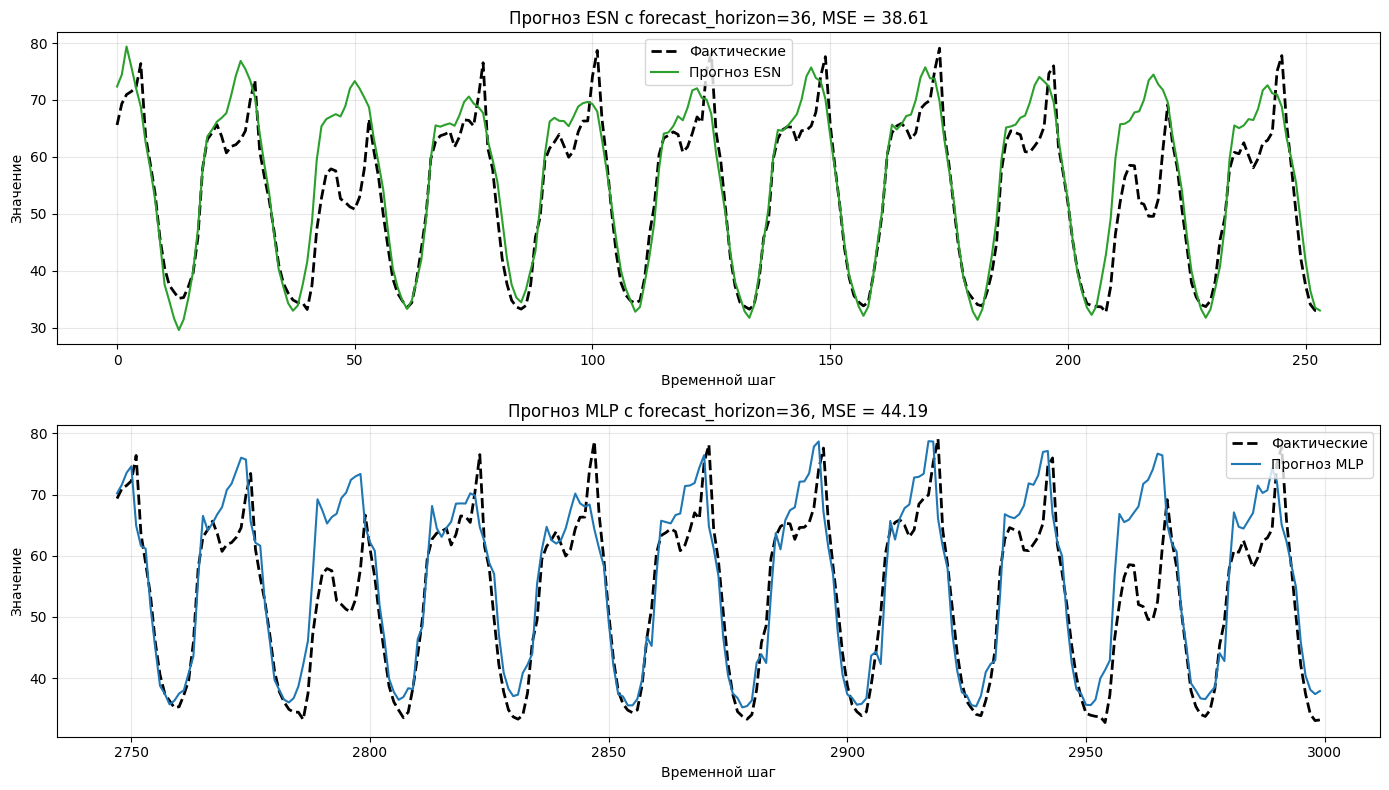

In [3]:
# ESN с forecast_horizon=36
from reservoir_computing.reservoir import Reservoir
from reservoir_computing.utils import make_forecasting_dataset
from sklearn.linear_model import Ridge

time_series_2d = time_series[:, None]
Xtr, Ytr, Xte, Yte, scaler_esn = make_forecasting_dataset(time_series_2d, horizon=36, test_percent=0.1)

res = Reservoir(n_internal_units=900, spectral_radius=0.99, input_scaling=0.1, connectivity=0.25)
n_drop = 10
states_tr = res.get_states(Xtr[None, :, :], n_drop=n_drop, bidir=False)
states_te = res.get_states(Xte[None, :, :], n_drop=n_drop, bidir=False)

ridge = Ridge(alpha=1.0)
ridge.fit(states_tr[0], Ytr[n_drop:, :])
Yhat = ridge.predict(states_te[0])
mse_esn_36 = mean_squared_error(scaler_esn.inverse_transform(Yhat.reshape(-1, 1)), Yte[n_drop:, :])
print(f"ESN с forecast_horizon=36: MSE = {mse_esn_36:.2f}")

# Обсуждение базового уровня
print("\nОбсуждение базового уровня:")
print("Использование mse = mean_squared_error(y_test[36:], y_test[:-36]) НЕ является хорошим базовым уровнем для horizon=36.")
print("Лучший базовый уровень: использовать значение от 24 шагов назад (суточная сезонность) как прогноз.")
print("Это учитывает суточный паттерн: y_pred(t) = y(t-24)")

# Вычисление лучшего базового уровня
baseline_mse = mean_squared_error(y_test[36:], y_test[:-36])
print(f"Базовый уровень персистентности (y(t+36) = y(t)): MSE = {baseline_mse:.2f}")

# График для Упражнения 2
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(Yte[n_drop:, :], label='Фактические', linewidth=2, color='black', linestyle='--')
axes[0].plot(scaler_esn.inverse_transform(Yhat.reshape(-1, 1)), label='Прогноз ESN', color='tab:green')
axes[0].set_title(f'Прогноз ESN с forecast_horizon=36, MSE = {mse_esn_36:.2f}')
axes[0].set_xlabel('Временной шаг')
axes[0].set_ylabel('Значение')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(time_steps[-len(y_test):], y_test, label='Фактические', linewidth=2, color='black', linestyle='--')
axes[1].plot(time_steps[-len(y_pred):], y_pred, label='Прогноз MLP', color='tab:blue')
axes[1].set_title(f'Прогноз MLP с forecast_horizon=36, MSE = {mse_mlp_36:.2f}')
axes[1].set_xlabel('Временной шаг')
axes[1].set_ylabel('Значение')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()

Упражнение 3: MLP и ESN на данных без тренда и сезонности
Loaded ElecRome dataset.
Data shape:
  X: (137376, 1)
MLP на остатках: MSE = 59.94
MLP на оригинальных данных: MSE = 26.97


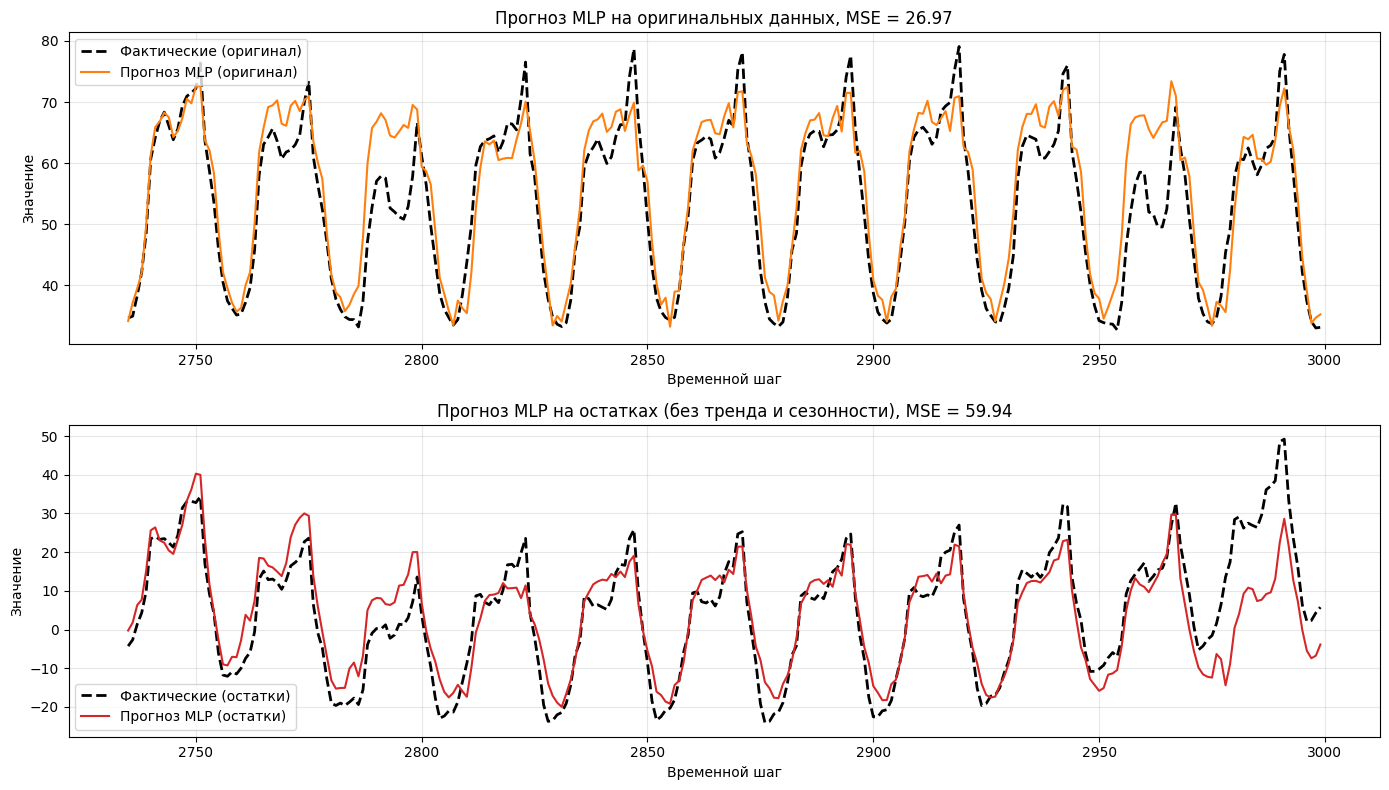

In [4]:
from scipy import signal
# Упражнение 3: Удалить тренд и сезонность
print("=" * 60)
print("Упражнение 3: MLP и ESN на данных без тренда и сезонности")
print("=" * 60)


# Загрузка свежих данных
ts_full = PredLoader().get_data('ElecRome')
ts_hourly = np.mean(ts_full.reshape(-1, 6), axis=1)
time_series = ts_hourly[0:3000]
train_size = int(0.9 * len(time_series))
tr = time_series[:train_size]
te = time_series[train_size:]

# Удаление тренда с помощью скользящего среднего и суточной сезонности
window_size_detrend = 24 * 7  # Недельное окно для тренда
trend = np.convolve(tr, np.ones(window_size_detrend)/window_size_detrend, mode='same')
detrended = tr - trend

# Удаление сезонности (24-часовой цикл)
hourly_means = np.array([detrended[i::24].mean() for i in range(24)])
deseasonalized = detrended.copy()
for i in range(24):
    deseasonalized[i::24] -= hourly_means[i]

# Для тестового набора используем статистику обучения
trend_te = np.convolve(te, np.ones(window_size_detrend)/window_size_detrend, mode='same')
detrended_te = te - trend_te
deseasonalized_te = detrended_te.copy()
for i in range(24):
    deseasonalized_te[i::24] -= hourly_means[i]

# Обучение MLP на остатках
window_size = 12
forecast_horizon = 24

X_train_res, y_train_res = create_windows(deseasonalized, window_size, forecast_horizon)
X_test_res, y_test_res = create_windows(deseasonalized_te, window_size, forecast_horizon)
y_train_res = y_train_res[:, -1]
y_test_res = y_test_res[:, -1]

scaler_res = StandardScaler()
X_train_scaled_res = scaler_res.fit_transform(X_train_res)
X_test_scaled_res = scaler_res.transform(X_test_res)

mlp_res = MLPRegressor(hidden_layer_sizes=(16, 8), activation='relu', solver='adam', max_iter=1000)
mlp_res.fit(X_train_scaled_res, y_train_res)
y_pred_res = mlp_res.predict(X_test_scaled_res)

# Для простоты сравниваем MSE на остатках
mse_residual = mean_squared_error(y_test_res, y_pred_res)
print(f"MLP на остатках: MSE = {mse_residual:.2f}")

# Сравнение с оригиналом (из Упражнения 1)
print(f"MLP на оригинальных данных: MSE = {mse_old:.2f}")

# График для Упражнения 3
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(time_steps[-len(y_test_old):], y_test_old, label='Фактические (оригинал)', linewidth=2, color='black', linestyle='--')
axes[0].plot(time_steps[-len(y_pred_old):], y_pred_old, label='Прогноз MLP (оригинал)', color='tab:orange')
axes[0].set_title(f'Прогноз MLP на оригинальных данных, MSE = {mse_old:.2f}')
axes[0].set_xlabel('Временной шаг')
axes[0].set_ylabel('Значение')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(time_steps[-len(y_test_res):], y_test_res, label='Фактические (остатки)', linewidth=2, color='black', linestyle='--')
axes[1].plot(time_steps[-len(y_pred_res):], y_pred_res, label='Прогноз MLP (остатки)', color='tab:red')
axes[1].set_title(f'Прогноз MLP на остатках (без тренда и сезонности), MSE = {mse_residual:.2f}')
axes[1].set_xlabel('Временной шаг')
axes[1].set_ylabel('Значение')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()

In [5]:
import statsmodels.api as sm
# Упражнение 4: Набор данных Key West Water Temperature
print("=" * 60)
print("Упражнение 4: Key West Water Temperature - Подбор гиперпараметров")
print("=" * 60)


temps = sm.datasets.get_rdataset("KeyWestWater", "Stat2Data").data
water_temp = temps["WaterTemp"].values
time_steps_temp = np.arange(0, len(water_temp))

# Разделение данных
train_size = int(0.9 * len(water_temp))
tr = water_temp[:train_size]
te = water_temp[train_size:]

# Поиск по сетке гиперпараметров MLP
print("\nПоиск гиперпараметров MLP:")
print("-" * 40)

hidden_layer_configs = [
    (16, 8),
    (16, 16, 8),
    (32, 16),
    (64, 32),
    (32,),
]
learning_rates = [0.001, 0.01]
activations = ['relu', 'tanh']

best_mlp_mse = float('inf')
best_mlp_config = None
best_mlp_pred = None

for hidden in hidden_layer_configs:
    for lr in learning_rates:
        for act in activations:
            X_train, y_train = create_windows(tr, window_size=12, forecast_horizon=24)
            y_train = y_train[:, -1]
            X_test, y_test = create_windows(te, window_size=12, forecast_horizon=24)
            y_test = y_test[:, -1]
            
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            
            try:
                mlp = MLPRegressor(hidden_layer_sizes=hidden, activation=act, 
                                   solver='adam', learning_rate_init=lr, max_iter=500)
                mlp.fit(X_train_scaled, y_train)
                y_pred = mlp.predict(X_test_scaled)
                mse = mean_squared_error(y_test, y_pred)
                
                if mse < best_mlp_mse:
                    best_mlp_mse = mse
                    best_mlp_config = (hidden, lr, act)
                    best_mlp_pred = y_pred
                    best_mlp_y_test = y_test
            except:
                continue

print(f"Лучшая конфигурация MLP: hidden_layers={best_mlp_config[0]}, lr={best_mlp_config[1]}, activation={best_mlp_config[2]}")
print(f"Лучший MSE MLP: {best_mlp_mse:.2f}")
# Поиск по сетке гиперпараметров ESN
print("\nПоиск гиперпараметров ESN:")
print("-" * 40)

Упражнение 4: Key West Water Temperature - Подбор гиперпараметров

Поиск гиперпараметров MLP:
----------------------------------------


/home/vlad/Programs/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Лучшая конфигурация MLP: hidden_layers=(32,), lr=0.01, activation=relu
Лучший MSE MLP: 1.71

Поиск гиперпараметров ESN:
----------------------------------------


Лучшая конфигурация ESN: spectral_radius=1.1, input_scaling=0.05, n_internal_units=300, connectivity=0.1
Лучший MSE ESN: 1.56

Итоги:
  Лучший MSE MLP: 1.71 с конфигурацией ((32,), 0.01, 'relu')
  Лучший MSE ESN: 1.56 с конфигурацией (1.1, 0.05, 300, 0.1)


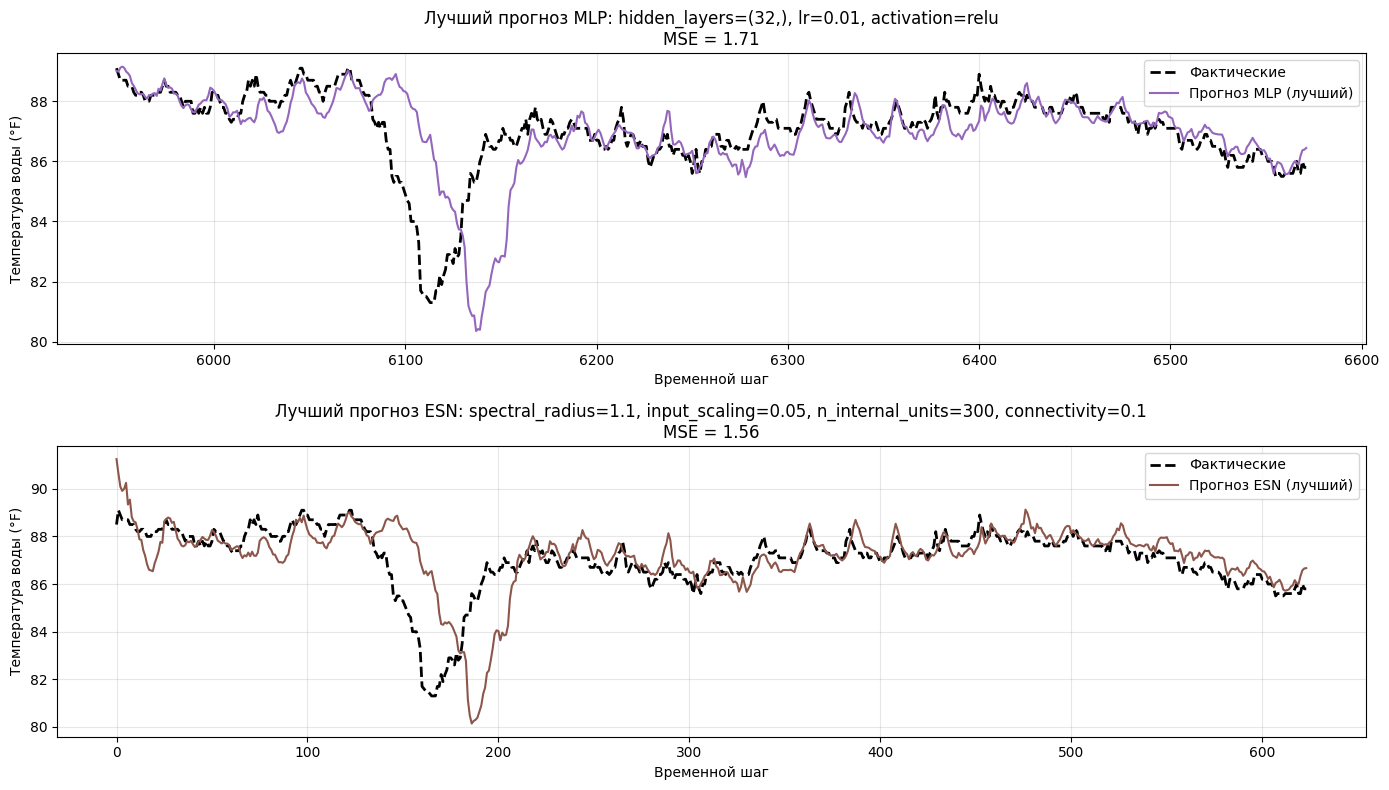

In [6]:
spectral_radii = [0.5, 0.9, 0.99, 1.1]
input_scalings = [0.05, 0.1, 0.2]
n_internal_units_list = [300, 600, 900]
connectivities = [0.1, 0.25, 0.5]

water_temp_2d = water_temp[:, None]

best_esn_mse = float('inf')
best_esn_config = None
best_esn_pred = None
best_esn_y_test = None

for sr in spectral_radii:
    for isc in input_scalings:
        for niu in n_internal_units_list:
            for conn in connectivities:
                try:
                    Xtr, Ytr, Xte, Yte, scaler_esn = make_forecasting_dataset(
                        water_temp_2d, horizon=24, test_percent=0.1)
                    
                    res = Reservoir(n_internal_units=niu, spectral_radius=sr, 
                                   input_scaling=isc, connectivity=conn)
                    n_drop = 10
                    states_tr = res.get_states(Xtr[None, :, :], n_drop=n_drop, bidir=False)
                    states_te = res.get_states(Xte[None, :, :], n_drop=n_drop, bidir=False)
                    
                    ridge = Ridge(alpha=1.0)
                    ridge.fit(states_tr[0], Ytr[n_drop:, :])
                    Yhat = ridge.predict(states_te[0])
                    mse = mean_squared_error(scaler_esn.inverse_transform(Yhat.reshape(-1, 1)), Yte[n_drop:, :])
                    
                    if mse < best_esn_mse:
                        best_esn_mse = mse
                        best_esn_config = (sr, isc, niu, conn)
                        best_esn_pred = scaler_esn.inverse_transform(Yhat.reshape(-1, 1))
                        best_esn_y_test = Yte[n_drop:, :]
                except:
                    continue

print(f"Лучшая конфигурация ESN: spectral_radius={best_esn_config[0]}, input_scaling={best_esn_config[1]}, n_internal_units={best_esn_config[2]}, connectivity={best_esn_config[3]}")
print(f"Лучший MSE ESN: {best_esn_mse:.2f}")

print("\n" + "=" * 60)
print("Итоги:")
print(f"  Лучший MSE MLP: {best_mlp_mse:.2f} с конфигурацией {best_mlp_config}")
print(f"  Лучший MSE ESN: {best_esn_mse:.2f} с конфигурацией {best_esn_config}")
print("=" * 60)

# График для Упражнения 4
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

test_start_idx = train_size + 12 + 24 - 1  # Начальный индекс тестовых данных
mlp_steps = np.arange(test_start_idx, test_start_idx + len(best_mlp_y_test))

axes[0].plot(mlp_steps, best_mlp_y_test, label='Фактические', linewidth=2, color='black', linestyle='--')
axes[0].plot(mlp_steps, best_mlp_pred, label=f'Прогноз MLP (лучший)', color='tab:purple')
axes[0].set_title(f'Лучший прогноз MLP: hidden_layers={best_mlp_config[0]}, lr={best_mlp_config[1]}, activation={best_mlp_config[2]}\nMSE = {best_mlp_mse:.2f}')
axes[0].set_xlabel('Временной шаг')
axes[0].set_ylabel('Температура воды (°F)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

esn_steps = np.arange(len(best_esn_y_test))
axes[1].plot(esn_steps, best_esn_y_test, label='Фактические', linewidth=2, color='black', linestyle='--')
axes[1].plot(esn_steps, best_esn_pred.flatten(), label=f'Прогноз ESN (лучший)', color='tab:brown')
axes[1].set_title(f'Лучший прогноз ESN: spectral_radius={best_esn_config[0]}, input_scaling={best_esn_config[1]}, n_internal_units={best_esn_config[2]}, connectivity={best_esn_config[3]}\nMSE = {best_esn_mse:.2f}')
axes[1].set_xlabel('Временной шаг')
axes[1].set_ylabel('Температура воды (°F)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()